In [1]:
# librerias necesarias
import pandas as pd
import sqlite3
import os

print("Carga de librerias...")

Carga de librerias...


In [2]:
# ruta al archivo CSV 
ruta_emprendedores = os.path.join('..', 'datos_iniciales', 'emprendedores.csv')
print (ruta_emprendedores)
# Carga del dataset 
df_emprendedores = pd.read_csv(ruta_emprendedores)

# presentacion de una muestra
df_emprendedores.head()

print("Carga archivo CSV lista...")

..\datos_iniciales\emprendedores.csv
Carga archivo CSV lista...


In [3]:
# Ruta archivo actividades
ruta_actividades_csv = os.path.join('..', 'datos_iniciales', 'actividades.csv')

# Ruta archivo Base de Datos
ruta_db = os.path.join('..', 'scripts_sql', 'base_actividades.db')

# Leer CSV actividades
df_actividades_temp = pd.read_csv(ruta_actividades_csv)

# Conectarse a SQLite
conexion = sqlite3.connect(ruta_db)

# guardar DataFrame en tabla registro_actividades
df_actividades_temp.to_sql('registro_actividades', conexion, if_exists='replace', index=False)

# Cerrar la conexión
conexion.close()

print("Base de datos: Base_emprendedores.db creada...")

Base de datos: Base_emprendedores.db creada...


In [4]:
# Conectarnos a la base de datos
conexion = sqlite3.connect(os.path.join('..', 'scripts_sql', 'base_actividades.db'))

# Prueba SQL para traer solo las primeras 5 filas
query = "SELECT * FROM registro_actividades"
df_actividades = pd.read_sql_query(query, conexion)

# 3. Cerrar la conexión
conexion.close()

# 4. Mostrar el resultado en pantalla


In [5]:
# 1. Realizar el cruce de datos (Merge)
# Usamos 'left' join para mantener a todos los emprendedores de tu maestro, 
# incluso si alguno de ellos aún no tiene actividades registradas.
df_consolidado = pd.merge(
    df_emprendedores, 
    df_actividades, 
    left_on='id_emprendedor', 
    right_on='id_persona', 
    how='left'
)

# 2. Definir la ruta de salida en la carpeta de 'datos_finales'
ruta_salida = os.path.join('..', 'datos_finales', 'ecosistema_consolidado.csv')

# 3. Exportar el archivo final unificado a un CSV limpio
df_consolidado.to_csv(ruta_salida, index=False)

print("🚀 ¡Proceso de unificación completado con éxito!")
print(f"📁 El archivo maestro consolidado ya descansa en: {ruta_salida}")
print(f"📊 El nuevo dataset tiene: {df_consolidado.shape[0]} filas y {df_consolidado.shape[1]} columnas.")

🚀 ¡Proceso de unificación completado con éxito!
📁 El archivo maestro consolidado ya descansa en: ..\datos_finales\ecosistema_consolidado.csv
📊 El nuevo dataset tiene: 33441 filas y 45 columnas.


In [6]:
df_consolidado.head(3)

,id_emprendedor,fecha_nacimiento,id_genero,id_ciudad,email,telefono,id_situacion_laboral,tipo_identificacion,id_nivel_academico,id_usuario,...,tema,id_evento,hora_fin,id_motivo_cancelar,id_tipo_asistencia,id_usuario_can,fecha_inscripcion_actividad,fecha_cancelacion,id_usuario_registro,id_registro_formulario
0,17198,1973-02-12,1.0,100.0,hotmail.com,981930205,2.0,C,4.0,16014.0,...,WEBINAR - CREACIÓN DE CONTENIDOS Y EVALUACIONE...,541.0,17:00,NaN,2.0,NaN,2025-04-20 19:54:02,NaN,20517.0,1665.0
1,17198,1973-02-12,1.0,100.0,hotmail.com,981930205,2.0,C,4.0,16014.0,...,EDUCACIÓN FINANCIERA EL CUAL INTEGRARÁ EL USO...,993.0,16:30,NaN,1.0,NaN,2026-02-19 21:39:16,NaN,20517.0,21958.0
2,17198,1973-02-12,1.0,100.0,hotmail.com,981930205,2.0,C,4.0,16014.0,...,MENTALIDAD QUE CONSTRUYE NEGOCIOS,1002.0,12:00,NaN,1.0,NaN,2026-03-02 20:46:18,NaN,20517.0,23943.0


In [7]:
# Ver información general de las columnas y tipos de datos
print("📋 Diagnóstico de estructura:")
df_consolidado.info()

# Contar cuántos datos nulos quedaron por columna
print("\n🔍 Cantidad de valores nulos por columna:")
print(df_consolidado.isnull().sum())

📋 Diagnóstico de estructura:
<class 'pandas.DataFrame'>
RangeIndex: 33441 entries, 0 to 33440
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_emprendedor               33441 non-null  int64  
 1   fecha_nacimiento             16607 non-null  str    
 2   id_genero                    32678 non-null  float64
 3   id_ciudad                    16398 non-null  float64
 4   email                        33439 non-null  str    
 5   telefono                     33310 non-null  str    
 6   id_situacion_laboral         16385 non-null  float64
 7   tipo_identificacion          33441 non-null  str    
 8   id_nivel_academico           16594 non-null  float64
 9   id_usuario                   1035 non-null   float64
 10  id_ciudad_nacimiento         31265 non-null  float64
 11  fecha_registro_perfil        33441 non-null  str    
 12  telefono_fijo                6636 non-null   str    
 13

In [8]:
# pygwalker
import pygwalker as pyg

# Lanza la interfaz interactiva dentro del notebook
walker = pyg.walk(df_consolidado)

Box(children=(HTML(value='\n<div id="ifr-pyg-000652e937c40576v56imwRqcP49Z1OI" style="height: auto">\n    <hea…

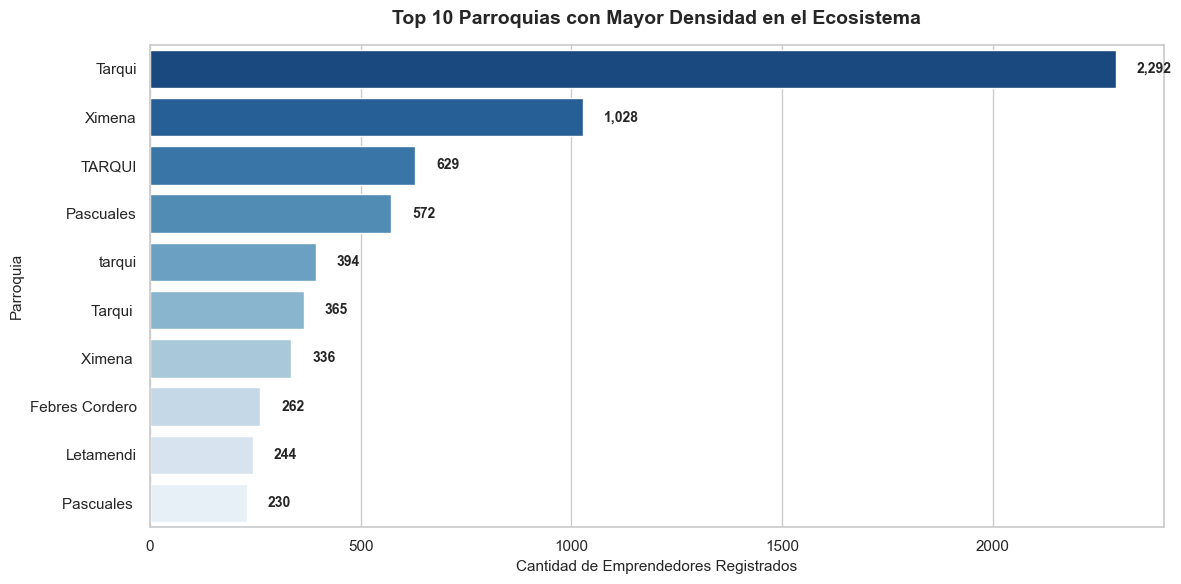

In [9]:
# matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Tratamiento de datos: filtrar nulos y contar las top 10 parroquias
df_geo = df_consolidado[df_consolidado['parroquia'].notna()]
top_parroquias = df_geo['parroquia'].value_counts().head(10)

# Crear gráfico de barras horizontales
sns.barplot(
    x=top_parroquias.values, 
    y=top_parroquias.index, 
    hue=top_parroquias.index,
    palette="Blues_r", 
    legend=False
)

# Detalles ejecutivos del gráfico
plt.title('Top 10 Parroquias con Mayor Densidad en el Ecosistema', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Emprendedores Registrados', fontsize=11)
plt.ylabel('Parroquia', fontsize=11)

# Añadir las etiquetas numéricas al final de cada barra para mayor claridad
for i, v in enumerate(top_parroquias.values):
    plt.text(v + 50, i, f'{v:,}', va='center', fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.show()

In [10]:
# bokeh
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import ColumnDataSource
from bokeh.transform import factor_cmap
from bokeh.palettes import Bright4

# Inicializar Bokeh para que se muestre dentro de Jupyter
output_notebook()

# Preparar los datos de asistencia (quitando los que no tienen eventos registrados)
df_asistencia = df_consolidado[df_consolidado['estado_asistencia_actividad'].notna()]
conteo_asistencia = df_asistencia['estado_asistencia_actividad'].value_counts().reset_index()
conteo_asistencia.columns = ['estado', 'total']

# Configurar fuente de datos de Bokeh
source = ColumnDataSource(conteo_asistencia)
estados_lista = conteo_asistencia['estado'].tolist()

# Crear la figura interactiva
p = figure(
    x_range=estados_lista, 
    height=400, 
    width=600, 
    title="Estado de Asistencia a Actividades y Eventos",
    toolbar_location="right", 
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

# Dibujar las barras con un mapa de colores dinámico
p.vbar(
    x='estado', 
    top='total', 
    width=0.6, 
    source=source,
    line_color='white',
    fill_color=factor_cmap('estado', palette=Bright4, factors=estados_lista)
)

# Estilo de etiquetas
p.xgrid.grid_line_color = None
p.y_range.start = 0
p.xaxis.axis_label = "Estado de la Inscripción"
p.yaxis.axis_label = "Cantidad de Registros"
p.title.text_font_size = '13pt'

# Mostrar el gráfico interactivo
show(p)

Loading BokehJS ...